# 01 · Q – Qualitätsprüfung

Quellen, Schema, Zielgrain, Missingness und amtliche Unsicherheit.

**Projekt:** MietCheck · Data Analytics & Big Data

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

COLORS = {"navy": "#14213D", "blue": "#2563EB", "teal": "#0F766E",
          "amber": "#F59E0B", "red": "#DC2626", "grey": "#64748B"}
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (9, 4.8), "axes.titleweight": "bold",
                     "axes.labelsize": 10, "figure.dpi": 110})

def load_json(relative_path):
    return json.loads((ROOT / relative_path).read_text(encoding="utf-8"))

print(f"Projektwurzel: {ROOT}")

Projektwurzel: C:\Users\nelek\Desktop\Big Data\MietCheck


## Qualitätslogik

Die Modellzeile ist eindeutig durch `GITTER_ID_100m × Gebäudealterklasse × Wohnungsgrößenklasse`. Kontextquellen werden zunächst je Gitterzelle validiert und anschließend als `many_to_one` an das Zielgrain gejoint. Zielwerte werden nie imputiert.

In [2]:
report = load_json("reports/dataset_build_report.json")
target = report["target"]
quality_summary = pd.DataFrame({
    "Kennzahl": ["Zeilen", "eindeutige Gitterzellen", "25-km-Blöcke",
                 "Zielminimum", "Zielmedian", "Zielmittel", "Zielmaximum",
                 "amtlich unsicherer Zielanteil"],
    "Wert": [report["rows"], report["unique_grid_cells"], report["spatial_blocks_25km"],
             target["min"], target["median"], target["mean"], target["max"],
             target["uncertain_share"]],
})
display(quality_summary)

,Kennzahl,Wert
0,Zeilen,2.058569e+06
1,eindeutige Gitterzellen,1.184386e+06
2,25-km-Blöcke,6.630000e+02
3,Zielminimum,1.000000e+00
4,Zielmedian,6.600000e+00
5,Zielmittel,7.059604e+00
6,Zielmaximum,4.959000e+01
7,amtlich unsicherer Zielanteil,1.149566e-01


,non_null_share,missing_share
dwelling_count,99.11%,0.89%
avg_household_size,99.65%,0.35%
ownership_rate_pct,99.79%,0.21%
vacancy_rate_pct,99.81%,0.19%
avg_dwelling_area_sqm,99.81%,0.19%
population,99.84%,0.16%


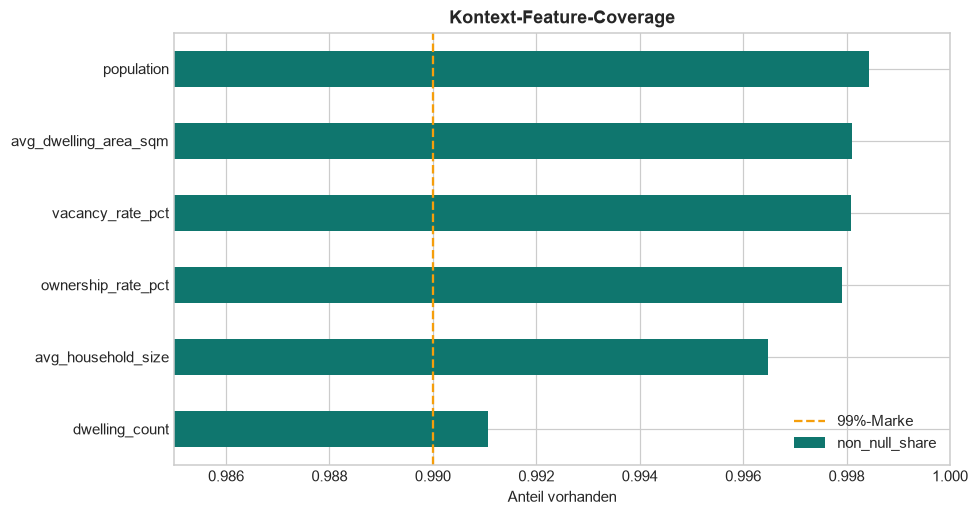

In [3]:
coverage = pd.Series(report["feature_non_null_share"], name="non_null_share")
coverage = coverage.sort_values().to_frame()
coverage["missing_share"] = 1 - coverage["non_null_share"]
display(coverage.style.format("{:.2%}"))

ax = coverage["non_null_share"].plot.barh(color=COLORS["teal"])
ax.axvline(0.99, color=COLORS["amber"], linestyle="--", label="99%-Marke")
ax.set(xlim=(0.985, 1.0), xlabel="Anteil vorhanden", ylabel="",
       title="Kontext-Feature-Coverage")
ax.legend(); plt.tight_layout(); plt.show()

In [4]:
sources = report["raw_source_manifest"]["sources"]
source_table = pd.DataFrame([
    {"key": key, "Datei": value["filename"], "MB": value["bytes"] / 1e6,
     "SHA-256 (kurz)": value["sha256"][:12], "Lizenz": value["license"]}
    for key, value in sources.items()
]).set_index("key")
display(source_table.round({"MB": 2}))

assert report["rows"] >= 2_000_000
assert report["unique_grid_cells"] >= 1_000_000
assert min(report["feature_non_null_share"].values()) >= 0.99
assert 0.5 <= target["min"] <= target["max"] <= 60
print("✓ Alle zentralen Datenqualitäts-Gates bestanden")

,Datei,MB,SHA-256 (kurz),Lizenz
key,,,,
zensus,zensus2022_rent_building_age_size.zip,16.68,0e18b007aa03,Datenlizenz Deutschland - Namensnennung - Vers...
greix,greix_city_metrics.xlsx,1.24,9382bf91aa5e,Published research data; observe the mandatory...
zensus_population,zensus2022_population.zip,18.50,1a8428d31eab,Datenlizenz Deutschland - Namensnennung - Vers...
zensus_household_size,zensus2022_average_household_size.zip,17.52,95765fea0b2f,Datenlizenz Deutschland - Namensnennung - Vers...
zensus_ownership,zensus2022_ownership_rate.zip,17.02,d7ae8558756c,Datenlizenz Deutschland - Namensnennung - Vers...
zensus_vacancy,zensus2022_vacancy_rate.zip,15.47,35d02a9f37b2,Datenlizenz Deutschland - Namensnennung - Vers...
zensus_dwelling_area,zensus2022_average_dwelling_area.zip,19.98,ea9d7fefb6ed,Datenlizenz Deutschland - Namensnennung - Vers...
zensus_rent_count,zensus2022_rent_and_dwelling_count.zip,11.04,c1b20e9be697,Datenlizenz Deutschland - Namensnennung - Vers...


✓ Alle zentralen Datenqualitäts-Gates bestanden


## Kritische Entscheidungen

- Das amtliche Zeichen `–` bedeutet in den ausgewählten Zensusdateien **exakt beziehungsweise auf 0 geändert**, nicht „fehlend“. Der Parser schützt diese Semantik mit Tests.
- `KLAMMERN` wird als Unsicherheitsflag erhalten.
- Das Unsicherheitsflag der **Zielmiete** wird nur ausgewertet, niemals als Feature verwendet.
- Die Roharchive bleiben unverändert; SHA-256-Hashes dokumentieren den exakten Stand.
- Keine Portal-Scrapes und keine personenbezogenen Daten.

---

**Reproduzierbarkeit:** Die visualisierten Kennzahlen stammen aus versionierten JSON-/CSV-Artefakten. Die jeweils genannten Skripte erzeugen diese Artefakte aus den öffentlichen Rohdaten erneut. Relative Pfade funktionieren sowohl aus der Projektwurzel als auch aus `notebooks/`.